# Retail Email Experiment — Experiment Audit

### Phase 1: Can we trust the experiment?

This notebook validates the Hillstrom retail email experiment before campaign
performance is interpreted. It is written for both business and technical readers.

**Business decision:** Determine whether the randomized customer groups and recorded
outcomes are reliable enough to support a comparison of the men's email, women's
email, and no-email control groups.

**Notebook outputs**

- `reports/tables/data_quality_summary.csv`
- `reports/tables/assignment_summary.csv`
- `reports/tables/covariate_balance.csv`
- `reports/figures/assignment_balance.png`
- `reports/figures/covariate_balance.png`

> This notebook performs experiment validation and descriptive orientation. Final
> campaign-effect estimates belong in `02_confirmatory_analysis.ipynb`.


## Audit Decision Criteria

The experiment will be considered suitable for the next analysis stage when:

1. required fields are present and outcome values are internally consistent;
2. no material sample-ratio mismatch is detected;
3. customer characteristics measured before the campaign are balanced across groups;
4. repeated rows are handled conservatively because the source provides no customer ID; and
5. limitations are documented before results are interpreted.

These checks do not prove that every aspect of the experiment is perfect. They assess
whether the available evidence reveals a material problem that would invalidate the
planned treatment comparisons.


## 1. Environment and Reproducibility


In [1]:
from pathlib import Path
import os
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

from IPython.display import Markdown, display
from scipy.stats import chisquare, chi2_contingency


# Configure notebook output
pd.set_option("display.max_columns", 50)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)


# Make randomized calculations reproducible
RANDOM_SEED = 2026
np.random.seed(RANDOM_SEED)


# Confirm the environment is ready
print("Libraries loaded successfully.")
print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"SciPy: {scipy.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Random seed: {RANDOM_SEED}")


mkdir -p failed for path /cloud/home/.config/matplotlib: [Errno 13] Permission denied: '/cloud/home/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-zx8mgmj6 because there was an issue with the default path (/cloud/home/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Libraries loaded successfully.
Python: 3.11.15
pandas: 2.3.3
NumPy: 2.4.6
SciPy: 1.17.1
Matplotlib: 3.11.2
Random seed: 2026


## 2. Locate and Load the Dataset

The raw CSV is intentionally excluded from version control. The code below searches
the standard repository locations so the notebook can run from either the repository
root or the `notebooks/` folder.

In Posit Cloud, place the CSV in `data/raw/` before running the notebook.


In [2]:
DATA_FILENAME = (
    "Kevin_Hillstrom_MineThatData_E-MailAnalytics_"
    "DataMiningChallenge_2008.03.20.csv"
)


def find_repository_root(start: Path) -> Path:
    # Return the nearest folder that looks like the project root.
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (
            (candidate / "notebooks").exists()
            or (candidate / "data").exists()
        ):
            return candidate
    return start


REPO_ROOT = find_repository_root(Path.cwd())
TABLE_DIR = REPO_ROOT / "reports" / "tables"
FIGURE_DIR = REPO_ROOT / "reports" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

environment_path = os.getenv("HILLSTROM_DATA_PATH")
candidates = []
if environment_path:
    candidates.append(Path(environment_path).expanduser())

candidates.extend(
    [
        REPO_ROOT / "data" / "raw" / DATA_FILENAME,
        Path.cwd() / "data" / "raw" / DATA_FILENAME,
        Path.cwd().parent / "data" / "raw" / DATA_FILENAME,
        Path.cwd() / DATA_FILENAME,
    ]
)

DATA_PATH = next((path.resolve() for path in candidates if path.exists()), None)

if DATA_PATH is None:
    checked = "\n".join(f"- {path}" for path in candidates)
    raise FileNotFoundError(
        "The Hillstrom CSV was not found. Place it under data/raw/ and rerun.\n"
        f"Locations checked:\n{checked}"
    )

print(f"Repository root: {REPO_ROOT}")
print(f"Dataset: {DATA_PATH}")
print(f"Tables will be saved to: {TABLE_DIR}")
print(f"Figures will be saved to: {FIGURE_DIR}")


Repository root: /cloud/project
Dataset: /cloud/project/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv
Tables will be saved to: /cloud/project/reports/tables
Figures will be saved to: /cloud/project/reports/figures


In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Rows: 64,000
Columns: 12


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.4400,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0000
1,6,3) $200 - $350,329.0800,1,1,Rural,1,Web,No E-Mail,0,0,0.0000
2,7,2) $100 - $200,180.6500,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0000
3,9,5) $500 - $750,675.8300,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0000
4,2,1) $0 - $100,45.3400,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0000


### What the Data Represents

Each row represents one customer record. Customer history was measured before the
campaign. Visit, conversion, and spend were measured during the two-week period after
campaign assignment.

The first five rows are displayed only to confirm that the file loaded correctly. They
should not be interpreted as representative customer examples.


In [4]:
schema_summary = pd.DataFrame(
    {
        "field": df.columns,
        "data_type": [str(dtype) for dtype in df.dtypes],
        "non_missing": [int(df[column].notna().sum()) for column in df.columns],
        "missing": [int(df[column].isna().sum()) for column in df.columns],
        "unique_values": [int(df[column].nunique(dropna=False)) for column in df.columns],
    }
)

display(schema_summary)


,field,data_type,non_missing,missing,unique_values
0,recency,int64,64000,0,12
1,history_segment,object,64000,0,7
2,history,float64,64000,0,34833
3,mens,int64,64000,0,2
4,womens,int64,64000,0,2
5,zip_code,object,64000,0,3
6,newbie,int64,64000,0,2
7,channel,object,64000,0,3
8,segment,object,64000,0,3
9,visit,int64,64000,0,2


## 3. Data-Quality and Outcome-Logic Checks


In [5]:
EXPECTED_COLUMNS = [
    "recency",
    "history_segment",
    "history",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel",
    "segment",
    "visit",
    "conversion",
    "spend",
]

BINARY_COLUMNS = ["mens", "womens", "newbie", "visit", "conversion"]
EXPECTED_SEGMENTS = {"No E-Mail", "Mens E-Mail", "Womens E-Mail"}

required_columns_missing = sorted(set(EXPECTED_COLUMNS) - set(df.columns))
unexpected_columns = sorted(set(df.columns) - set(EXPECTED_COLUMNS))
invalid_binary_rows = int(
    (~df[BINARY_COLUMNS].isin([0, 1])).any(axis=1).sum()
)
unexpected_segment_rows = int((~df["segment"].isin(EXPECTED_SEGMENTS)).sum())

quality_results = [
    ("Customer records", len(df), "Informational"),
    ("Data fields", df.shape[1], "Informational"),
    ("Missing required columns", len(required_columns_missing), "Pass when 0"),
    ("Unexpected columns", len(unexpected_columns), "Review when above 0"),
    ("Missing cells", int(df.isna().sum().sum()), "Pass when 0"),
    ("Rows with invalid binary values", invalid_binary_rows, "Pass when 0"),
    ("Rows with unexpected experiment groups", unexpected_segment_rows, "Pass when 0"),
    ("Conversions without a visit", int(((df["conversion"] == 1) & (df["visit"] == 0)).sum()), "Pass when 0"),
    ("Positive spend without conversion", int(((df["spend"] > 0) & (df["conversion"] == 0)).sum()), "Pass when 0"),
    ("Conversions with zero spend", int(((df["conversion"] == 1) & (df["spend"] <= 0)).sum()), "Pass when 0"),
    ("Negative historical spend", int((df["history"] < 0).sum()), "Pass when 0"),
    ("Negative outcome spend", int((df["spend"] < 0).sum()), "Pass when 0"),
]

data_quality_summary = pd.DataFrame(
    quality_results,
    columns=["check", "result", "interpretation"],
)
display(data_quality_summary)

data_quality_path = TABLE_DIR / "data_quality_summary.csv"
data_quality_summary.to_csv(data_quality_path, index=False)
print(f"Saved: {data_quality_path}")


,check,result,interpretation
0,Customer records,64000,Informational
1,Data fields,12,Informational
2,Missing required columns,0,Pass when 0
3,Unexpected columns,0,Review when above 0
4,Missing cells,0,Pass when 0
5,Rows with invalid binary values,0,Pass when 0
6,Rows with unexpected experiment groups,0,Pass when 0
7,Conversions without a visit,0,Pass when 0
8,Positive spend without conversion,0,Pass when 0
9,Conversions with zero spend,0,Pass when 0


Saved: /cloud/project/reports/tables/data_quality_summary.csv


### Why These Checks Matter

The outcome relationships should be logically consistent. For example, a customer
should not be recorded as converting without visiting, and positive spend should not
appear without a recorded conversion. A violation would require investigation before
comparing campaign results.


## 4. Repeated Rows and the Missing Customer Identifier


In [6]:
identical_observed_rows = int(df.duplicated().sum())
identical_row_share = identical_observed_rows / len(df)

duplicate_summary = pd.DataFrame(
    {
        "measure": ["Identical observed rows", "Share of all records"],
        "value": [f"{identical_observed_rows:,}", f"{identical_row_share:.2%}"],
    }
)
display(duplicate_summary)


,measure,value
0,Identical observed rows,"6,562"
1,Share of all records,10.25%


**Audit treatment of repeated rows:** The source file does not include a customer ID.
Different customers can therefore have identical recorded characteristics and outcomes.
The 6,562 repeated observations are retained because deleting them could remove valid
experimental units. They should be described as *identical observed rows*, not confirmed
duplicate customers.


## 5. Experiment Assignment and Sample-Ratio Check


In [7]:
ARM_ORDER = ["No E-Mail", "Mens E-Mail", "Womens E-Mail"]
ARM_LABELS = {
    "No E-Mail": "No email",
    "Mens E-Mail": "Men's email",
    "Womens E-Mail": "Women's email",
}
ARM_COLORS = {
    "No E-Mail": "#6B7280",
    "Mens E-Mail": "#0072B2",
    "Womens E-Mail": "#CC79A7",
}

arm_counts = df["segment"].value_counts().reindex(ARM_ORDER)
expected_count = len(df) / len(ARM_ORDER)
srm_statistic, srm_p_value = chisquare(arm_counts.to_numpy())

assignment_summary = pd.DataFrame(
    {
        "experiment_group": [ARM_LABELS[arm] for arm in ARM_ORDER],
        "source_group_label": ARM_ORDER,
        "customer_count": arm_counts.to_numpy(dtype=int),
        "share": (arm_counts / len(df)).to_numpy(),
        "expected_count_equal_assignment": expected_count,
        "difference_from_expected": (arm_counts - expected_count).to_numpy(),
        "sample_ratio_chi_square": srm_statistic,
        "sample_ratio_p_value": srm_p_value,
    }
)

assignment_display = assignment_summary.copy()
assignment_display["customer_count"] = assignment_display["customer_count"].map(lambda value: f"{value:,.0f}")
assignment_display["share"] = assignment_display["share"].map(lambda value: f"{value:.2%}")
assignment_display["expected_count_equal_assignment"] = assignment_display["expected_count_equal_assignment"].map(lambda value: f"{value:,.1f}")
assignment_display["difference_from_expected"] = assignment_display["difference_from_expected"].map(lambda value: f"{value:+,.1f}")
assignment_display["sample_ratio_chi_square"] = assignment_display["sample_ratio_chi_square"].map(lambda value: f"{value:.4f}")
assignment_display["sample_ratio_p_value"] = assignment_display["sample_ratio_p_value"].map(lambda value: f"{value:.4f}")
display(assignment_display)

assignment_path = TABLE_DIR / "assignment_summary.csv"
assignment_summary.to_csv(assignment_path, index=False)
print(f"Saved: {assignment_path}")


,experiment_group,source_group_label,customer_count,share,expected_count_equal_assignment,difference_from_expected,sample_ratio_chi_square,sample_ratio_p_value
0,No email,No E-Mail,"21,306",33.29%,"21,333.3",-27.3,0.2025,0.9037
1,Men's email,Mens E-Mail,"21,307",33.29%,"21,333.3",-26.3,0.2025,0.9037
2,Women's email,Womens E-Mail,"21,387",33.42%,"21,333.3",+53.7,0.2025,0.9037


Saved: /cloud/project/reports/tables/assignment_summary.csv


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x_positions = np.arange(len(ARM_ORDER))
bars = ax.bar(
    x_positions,
    arm_counts.to_numpy(),
    color=[ARM_COLORS[arm] for arm in ARM_ORDER],
    width=0.65,
)

ax.axhline(
    expected_count,
    color="#111827",
    linestyle="--",
    linewidth=1.4,
    label=f"Expected under equal assignment ({expected_count:,.0f})",
)
ax.set_xticks(x_positions, [ARM_LABELS[arm] for arm in ARM_ORDER])
ax.set_ylabel("Customers assigned")
ax.set_title("Experiment Groups Are Nearly Equal in Size", weight="bold", pad=14)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, loc="upper right")

for bar, value in zip(bars, arm_counts.to_numpy()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 75,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        weight="bold",
    )

ax.set_ylim(0, max(arm_counts) * 1.13)
fig.tight_layout()

assignment_figure_path = FIGURE_DIR / "assignment_balance.png"
fig.savefig(assignment_figure_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {assignment_figure_path}")


In [8]:
if srm_p_value >= 0.05:
    srm_message = (
        f"**Plain-language conclusion:** The assignment counts are consistent with "
        f"the planned equal allocation. No sample-ratio problem was detected "
        f"(chi-square = {srm_statistic:.3f}, p = {srm_p_value:.3f})."
    )
else:
    srm_message = (
        f"**Review required:** The group counts differ more than expected under equal "
        f"assignment (chi-square = {srm_statistic:.3f}, p = {srm_p_value:.3f})."
    )

display(Markdown(srm_message))


**Plain-language conclusion:** The assignment counts are consistent with the planned equal allocation. No sample-ratio problem was detected (chi-square = 0.203, p = 0.904).

### Interpreting the Sample-Ratio Test

A sample-ratio mismatch test asks whether the observed group sizes differ more than
expected from ordinary random variation. A large p-value does not prove that assignment
was flawless; it indicates that the group counts do not reveal evidence of a material
allocation problem.


## 6. Pretreatment Customer Balance


Random assignment should create customer groups that are similar before the emails are
sent. This section compares pretreatment customer characteristics.

- **Standardized mean difference (SMD):** measures the size of a numeric or binary
  difference in standard-deviation units. Values near zero indicate balance.
- **Cramer's V:** measures association between a categorical characteristic and campaign
  assignment. Values near zero indicate little association.

An absolute SMD below 0.10 and Cramer's V below 0.10 are used as practical review
thresholds, not as automatic proof of perfect randomization.


In [9]:
CONTROL_ARM = "No E-Mail"
TREATMENT_ARMS = ["Mens E-Mail", "Womens E-Mail"]
NUMERIC_AND_BINARY_COVARIATES = [
    "recency",
    "history",
    "mens",
    "womens",
    "newbie",
]
CATEGORICAL_COVARIATES = ["history_segment", "zip_code", "channel"]


def standardized_mean_difference(
    treatment_values: pd.Series,
    control_values: pd.Series,
) -> float:
    treatment_variance = treatment_values.var(ddof=1)
    control_variance = control_values.var(ddof=1)
    pooled_sd = np.sqrt((treatment_variance + control_variance) / 2)
    if pooled_sd == 0:
        return 0.0
    return float((treatment_values.mean() - control_values.mean()) / pooled_sd)


balance_records = []

control = df[df["segment"] == CONTROL_ARM]

for variable in NUMERIC_AND_BINARY_COVARIATES:
    for treatment_arm in TREATMENT_ARMS:
        treatment = df[df["segment"] == treatment_arm]
        smd = standardized_mean_difference(treatment[variable], control[variable])
        balance_records.append(
            {
                "variable": variable,
                "variable_type": "numeric_or_binary",
                "comparison": f"{ARM_LABELS[treatment_arm]} vs no email",
                "metric": "standardized_mean_difference",
                "value": smd,
                "treatment_mean": treatment[variable].mean(),
                "control_mean": control[variable].mean(),
                "p_value": np.nan,
            }
        )

for variable in CATEGORICAL_COVARIATES:
    contingency_table = pd.crosstab(df[variable], df["segment"])
    chi_square, p_value, _, _ = chi2_contingency(contingency_table)
    observations = contingency_table.to_numpy().sum()
    minimum_dimension = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi_square / (observations * minimum_dimension))
    balance_records.append(
        {
            "variable": variable,
            "variable_type": "categorical",
            "comparison": "All experiment groups",
            "metric": "cramers_v",
            "value": cramers_v,
            "treatment_mean": np.nan,
            "control_mean": np.nan,
            "p_value": p_value,
        }
    )

covariate_balance = pd.DataFrame(balance_records)
covariate_balance_path = TABLE_DIR / "covariate_balance.csv"
covariate_balance.to_csv(covariate_balance_path, index=False)

covariate_balance_display = covariate_balance.copy()
for column in ["value", "treatment_mean", "control_mean", "p_value"]:
    covariate_balance_display[column] = covariate_balance_display[column].map(
        lambda value: "—" if pd.isna(value) else f"{value:.4f}"
    )
display(covariate_balance_display)
print(f"Saved: {covariate_balance_path}")


,variable,variable_type,comparison,metric,value,treatment_mean,control_mean,p_value
0,recency,numeric_or_binary,Men's email vs no email,standardized_mean_difference,0.0068,5.7736,5.7497,—
1,recency,numeric_or_binary,Women's email vs no email,standardized_mean_difference,0.0052,5.7678,5.7497,—
2,history,numeric_or_binary,Men's email vs no email,standardized_mean_difference,0.0076,242.8359,240.8827,—
3,history,numeric_or_binary,Women's email vs no email,standardized_mean_difference,0.0065,242.5366,240.8827,—
4,mens,numeric_or_binary,Men's email vs no email,standardized_mean_difference,-0.0046,0.5509,0.5532,—
5,mens,numeric_or_binary,Women's email vs no email,standardized_mean_difference,-0.0086,0.5489,0.5532,—
6,womens,numeric_or_binary,Men's email vs no email,standardized_mean_difference,0.0076,0.5514,0.5476,—
7,womens,numeric_or_binary,Women's email vs no email,standardized_mean_difference,0.0049,0.5501,0.5476,—
8,newbie,numeric_or_binary,Men's email vs no email,standardized_mean_difference,-0.0009,0.5015,0.5020,—
9,newbie,numeric_or_binary,Women's email vs no email,standardized_mean_difference,0.0026,0.5032,0.5020,—


Saved: /cloud/project/reports/tables/covariate_balance.csv


In [ ]:
numeric_balance = covariate_balance[
    covariate_balance["metric"] == "standardized_mean_difference"
].copy()

comparison_order = [
    "Men's email vs no email",
    "Women's email vs no email",
]
comparison_colors = {
    "Men's email vs no email": ARM_COLORS["Mens E-Mail"],
    "Women's email vs no email": ARM_COLORS["Womens E-Mail"],
}

variables = NUMERIC_AND_BINARY_COVARIATES
y_positions = np.arange(len(variables))
offsets = {
    "Men's email vs no email": -0.10,
    "Women's email vs no email": 0.10,
}

fig, ax = plt.subplots(figsize=(10, 6))

for comparison in comparison_order:
    subset = (
        numeric_balance[numeric_balance["comparison"] == comparison]
        .set_index("variable")
        .reindex(variables)
    )
    ax.scatter(
        subset["value"],
        y_positions + offsets[comparison],
        s=85,
        color=comparison_colors[comparison],
        label=comparison,
        zorder=3,
    )

ax.axvline(0, color="#111827", linewidth=1.2)
ax.axvline(-0.10, color="#9CA3AF", linestyle="--", linewidth=1.1)
ax.axvline(0.10, color="#9CA3AF", linestyle="--", linewidth=1.1)
ax.set_yticks(y_positions, variables)
ax.set_xlabel("Standardized mean difference")
ax.set_title("Pretreatment Customer Characteristics Are Well Balanced", weight="bold", pad=14)
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
ax.set_xlim(-0.12, 0.12)
fig.tight_layout()

covariate_figure_path = FIGURE_DIR / "covariate_balance.png"
fig.savefig(covariate_figure_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {covariate_figure_path}")


In [11]:
# Separate the numeric/binary balance results
numeric_balance = covariate_balance[
    covariate_balance["metric"] == "standardized_mean_difference"
].copy()


# Separate the categorical balance results
categorical_balance = covariate_balance[
    covariate_balance["metric"] == "cramers_v"
][
    ["variable", "value", "p_value"]
].rename(
    columns={"value": "cramers_v"}
)


# Create a formatted display table
categorical_balance_display = categorical_balance.copy()

categorical_balance_display["cramers_v"] = (
    categorical_balance_display["cramers_v"]
    .map(lambda value: f"{value:.4f}")
)

categorical_balance_display["p_value"] = (
    categorical_balance_display["p_value"]
    .map(lambda value: f"{value:.4f}")
)

display(categorical_balance_display)


# Calculate the largest observed balance measures
max_absolute_smd = numeric_balance["value"].abs().max()
max_cramers_v = categorical_balance["cramers_v"].max()


# Display the plain-language conclusion
display(
    Markdown(
        f"**Plain-language conclusion:** The largest absolute standardized "
        f"mean difference is **{max_absolute_smd:.3f}**, and the largest "
        f"Cramer's V is **{max_cramers_v:.3f}**. Both are well below the "
        "0.10 review threshold. The observed pretreatment characteristics "
        "are closely balanced across groups."
    )
)


,variable,cramers_v,p_value
10,history_segment,0.0101,0.3580
11,zip_code,0.0047,0.5795
12,channel,0.0053,0.4580


**Plain-language conclusion:** The largest absolute standardized mean difference is **0.009**, and the largest Cramer's V is **0.010**. Both are well below the 0.10 review threshold. The observed pretreatment characteristics are closely balanced across groups.

## 7. Preliminary Descriptive Outcomes


The following table is included only to orient the reader. It does not replace the
confirmatory analysis, uncertainty estimates, or multiple-comparison controls planned
for the next notebook.


In [12]:
arm_metrics = (
    df.groupby("segment", observed=True)
    .agg(
        customers=("segment", "size"),
        visits=("visit", "sum"),
        visit_rate=("visit", "mean"),
        conversions=("conversion", "sum"),
        conversion_rate=("conversion", "mean"),
        total_revenue=("spend", "sum"),
        revenue_per_customer=("spend", "mean"),
    )
    .reindex(ARM_ORDER)
    .rename(index=ARM_LABELS)
)

arm_metrics_display = arm_metrics.copy()
for column in ["customers", "visits", "conversions"]:
    arm_metrics_display[column] = arm_metrics_display[column].map(lambda value: f"{value:,.0f}")
for column in ["visit_rate", "conversion_rate"]:
    arm_metrics_display[column] = arm_metrics_display[column].map(lambda value: f"{value:.2%}")
for column in ["total_revenue", "revenue_per_customer"]:
    arm_metrics_display[column] = arm_metrics_display[column].map(lambda value: f"${value:,.2f}")
display(arm_metrics_display)


,customers,visits,visit_rate,conversions,conversion_rate,total_revenue,revenue_per_customer
segment,,,,,,,
No email,"21,306","2,262",10.62%,122,0.57%,"$13,908.33",$0.65
Men's email,"21,307","3,894",18.28%,267,1.25%,"$30,311.69",$1.42
Women's email,"21,387","3,238",15.14%,189,0.88%,"$23,038.11",$1.08


**Descriptive interpretation:** Both email groups show higher visit, conversion, and
revenue-per-customer values than the no-email group. The men's email has the highest
observed values. The next notebook will quantify the campaign effects and their
uncertainty before a final recommendation is made.


## 8. Final Audit Decision


In [13]:
critical_quality_checks = data_quality_summary[
    data_quality_summary["interpretation"].eq("Pass when 0")
]

integrity_clear = bool((critical_quality_checks["result"] == 0).all())
assignment_clear = bool(srm_p_value >= 0.05)
numeric_balance_clear = bool(max_absolute_smd < 0.10)
categorical_balance_clear = bool(max_cramers_v < 0.10)

audit_decision = pd.DataFrame(
    {
        "audit_area": [
            "Data integrity",
            "Experiment-group allocation",
            "Numeric and binary covariate balance",
            "Categorical covariate balance",
        ],
        "criterion_met": [
            integrity_clear,
            assignment_clear,
            numeric_balance_clear,
            categorical_balance_clear,
        ],
    }
)

display(audit_decision)

experiment_ready = bool(audit_decision["criterion_met"].all())

if experiment_ready:
    final_message = '''
    ## Audit Result: Suitable for Confirmatory Analysis

    The dataset passes the planned integrity, assignment, and pretreatment-balance
    checks. No material issue was detected that would prevent estimation of the
    incremental effects of the men's and women's email campaigns.

    Identical observed rows are retained because the source provides no customer ID.
    The next step is `02_confirmatory_analysis.ipynb`, which will estimate campaign
    effects, confidence intervals, bootstrap revenue uncertainty, and adjusted
    significance results.
    '''
else:
    final_message = '''
    ## Audit Result: Review Required

    At least one planned audit criterion was not met. Review the failed area before
    proceeding to confirmatory campaign-effect analysis.
    '''

display(Markdown(final_message))


,audit_area,criterion_met
0,Data integrity,True
1,Experiment-group allocation,True
2,Numeric and binary covariate balance,True
3,Categorical covariate balance,True



    ## Audit Result: Suitable for Confirmatory Analysis

    The dataset passes the planned integrity, assignment, and pretreatment-balance
    checks. No material issue was detected that would prevent estimation of the
    incremental effects of the men's and women's email campaigns.

    Identical observed rows are retained because the source provides no customer ID.
    The next step is `02_confirmatory_analysis.ipynb`, which will estimate campaign
    effects, confidence intervals, bootstrap revenue uncertainty, and adjusted
    significance results.
    

## 9. Confirm Generated Portfolio Outputs


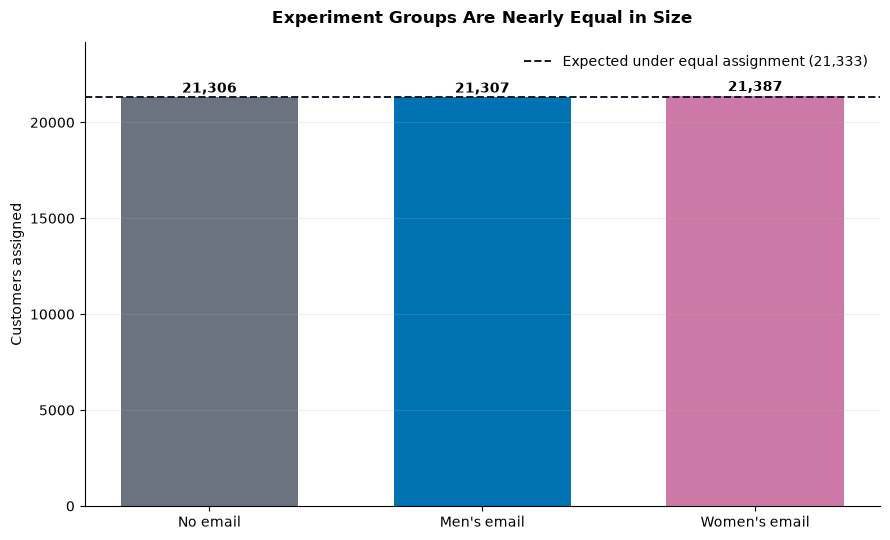

Saved: /cloud/project/reports/figures/assignment_balance.png


In [15]:
#Create assignment_balance.png

fig, ax = plt.subplots(figsize=(9, 5.5))

x_positions = np.arange(len(ARM_ORDER))

bars = ax.bar(
    x_positions,
    arm_counts.to_numpy(),
    color=[ARM_COLORS[arm] for arm in ARM_ORDER],
    width=0.65,
)

ax.axhline(
    expected_count,
    color="#111827",
    linestyle="--",
    linewidth=1.4,
    label=f"Expected under equal assignment ({expected_count:,.0f})",
)

ax.set_xticks(
    x_positions,
    [ARM_LABELS[arm] for arm in ARM_ORDER],
)

ax.set_ylabel("Customers assigned")
ax.set_title(
    "Experiment Groups Are Nearly Equal in Size",
    weight="bold",
    pad=14,
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, loc="upper right")

for bar, value in zip(bars, arm_counts.to_numpy()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 75,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        weight="bold",
    )

ax.set_ylim(0, max(arm_counts) * 1.13)
fig.tight_layout()

assignment_figure_path = (
    FIGURE_DIR / "assignment_balance.png"
)

fig.savefig(
    assignment_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {assignment_figure_path}")

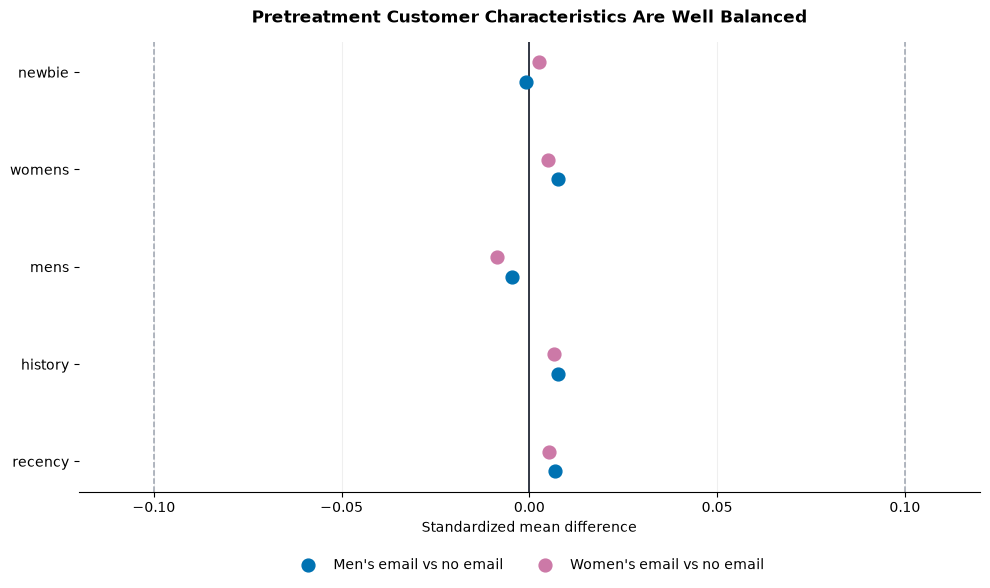

Saved: /cloud/project/reports/figures/covariate_balance.png


In [16]:
#Create covariate_balance.png

numeric_balance = covariate_balance[
    covariate_balance["metric"]
    == "standardized_mean_difference"
].copy()

comparison_order = [
    "Men's email vs no email",
    "Women's email vs no email",
]

comparison_colors = {
    "Men's email vs no email": ARM_COLORS["Mens E-Mail"],
    "Women's email vs no email": ARM_COLORS["Womens E-Mail"],
}

variables = NUMERIC_AND_BINARY_COVARIATES
y_positions = np.arange(len(variables))

offsets = {
    "Men's email vs no email": -0.10,
    "Women's email vs no email": 0.10,
}

fig, ax = plt.subplots(figsize=(10, 6))

for comparison in comparison_order:
    subset = (
        numeric_balance[
            numeric_balance["comparison"] == comparison
        ]
        .set_index("variable")
        .reindex(variables)
    )

    ax.scatter(
        subset["value"],
        y_positions + offsets[comparison],
        s=85,
        color=comparison_colors[comparison],
        label=comparison,
        zorder=3,
    )

ax.axvline(0, color="#111827", linewidth=1.2)
ax.axvline(
    -0.10,
    color="#9CA3AF",
    linestyle="--",
    linewidth=1.1,
)
ax.axvline(
    0.10,
    color="#9CA3AF",
    linestyle="--",
    linewidth=1.1,
)

ax.set_yticks(y_positions, variables)
ax.set_xlabel("Standardized mean difference")

ax.set_title(
    "Pretreatment Customer Characteristics Are Well Balanced",
    weight="bold",
    pad=14,
)

ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right", "left"]].set_visible(False)

ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
)

ax.set_xlim(-0.12, 0.12)
fig.tight_layout()

covariate_figure_path = (
    FIGURE_DIR / "covariate_balance.png"
)

fig.savefig(
    covariate_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {covariate_figure_path}")

In [17]:
expected_outputs = [
    TABLE_DIR / "data_quality_summary.csv",
    TABLE_DIR / "assignment_summary.csv",
    TABLE_DIR / "covariate_balance.csv",
    FIGURE_DIR / "assignment_balance.png",
    FIGURE_DIR / "covariate_balance.png",
]

output_check = pd.DataFrame(
    {
        "output": [str(path.relative_to(REPO_ROOT)) for path in expected_outputs],
        "created": [path.exists() for path in expected_outputs],
        "size_bytes": [path.stat().st_size if path.exists() else 0 for path in expected_outputs],
    }
)
display(output_check)

if not output_check["created"].all():
    raise RuntimeError("One or more expected portfolio outputs were not created.")


,output,created,size_bytes
0,reports/tables/data_quality_summary.csv,True,510
1,reports/tables/assignment_summary.csv,True,513
2,reports/tables/covariate_balance.csv,True,1761
3,reports/figures/assignment_balance.png,True,62270
4,reports/figures/covariate_balance.png,True,70617


## Posit Cloud Completion Checklist

Before downloading the executed notebook:

1. Restart the Python kernel.
2. Run all cells from top to bottom.
3. Confirm that no cell reports an error.
4. Confirm that both figures display correctly.
5. Confirm that all five output files were created.
6. Save the notebook with its output cells visible.
7. Download the executed `.ipynb` file and the generated `reports/` files.

When the executed notebook is added to GitHub, reviewers will be able to inspect the
audit narrative and results without downloading the raw CSV.
